## Goal

After preprocessing a binary image will have:

- walls
- noise blobs 
- text remnants

This notebook performs segmentation on that preprocessed floor plan image and aims to separate:

- walls (main structural elements)
- background noise

The output will be a binary mask used in later vectorization.

In [17]:
import sys
from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.visualization import show_images
from src.io_utils import load_image
from src.preprocessing import FloorPlanPreprocessor

## Load and Preprocess Rectified Image

In [18]:
rectified = load_image("../output/rectified_floor_plan.png")

In [19]:
preprocessor = FloorPlanPreprocessor(
    gamma=1.1,
    thresh_block=31, 
    thresh_C=10,
    resize=(512, 512),
    kernel=np.ones((7,7), np.uint8),
)

binary = preprocessor.process(rectified)

print(binary.shape, binary.min(), binary.max())

(512, 512) 0.0 1.0


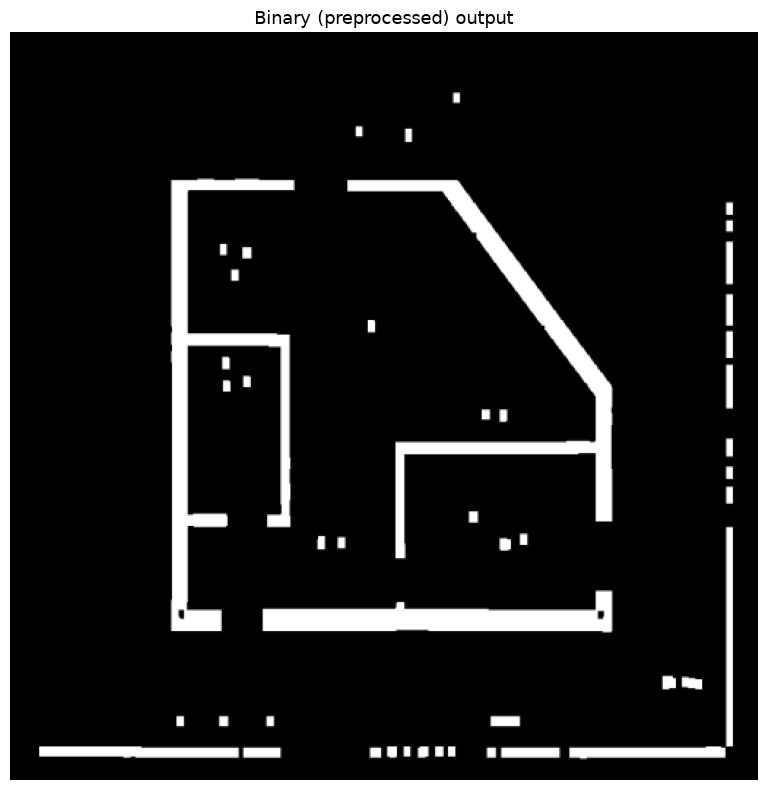

In [20]:
show_images(
    [binary],
    ["Binary (preprocessed) output"],
    )

## Isolate walls

### Connected Component Filtering

The preprocessed binary image still contains regions that do not belong to the plan structure, such as text, isolated noise, or other artifacts. The goal of this step is to identify every connected foreground object and remove those that are too small to represent walls.

`cv2.connectedComponentsWithStats()` labels each connected foreground region with a unique integer identifier and computes several statistics for every component. Components whose area is smaller than a chosen threshold are discarded, producing a cleaner wall mask for subsequent processing.

For wall segmentation, 8-connectivity is preferred because walls often touch diagonally after thresholding.

In [21]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    (binary * 255).astype(np.uint8),
    connectivity=8
)

In [22]:
print("Total number of connected components, including the background :", num_labels)

Total number of connected components, including the background : 47


In [23]:
mask = np.zeros_like(binary)

min_area = 2200   # tuned

for i in range(1, num_labels):  # skip background (label 0 is always the background)
    area = stats[i, cv2.CC_STAT_AREA] # pixel area of the current connected component
    if area > min_area:
        mask[labels == i] = 1

The result is a binary image (mask) containing only large structural elements.

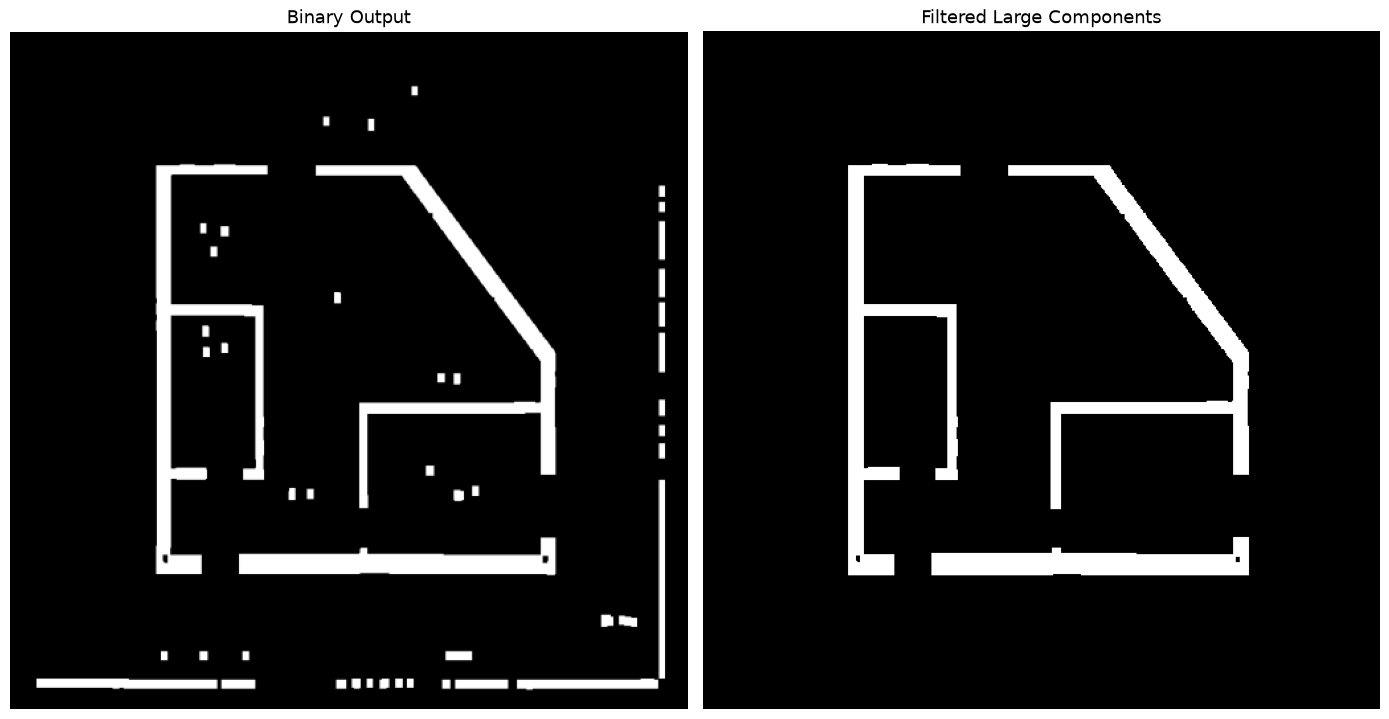

In [24]:
show_images(
    [binary, mask], 
    ["Binary Output", "Filtered Large Components"],
    )

## Morphological “wall strengthening”

Even if pipeline is good, walls are often:

- broken
- dotted
- not fully connected

So we explicitly enforce structure:

In [25]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

clean_mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel, iterations=2)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_OPEN, kernel, iterations=1)

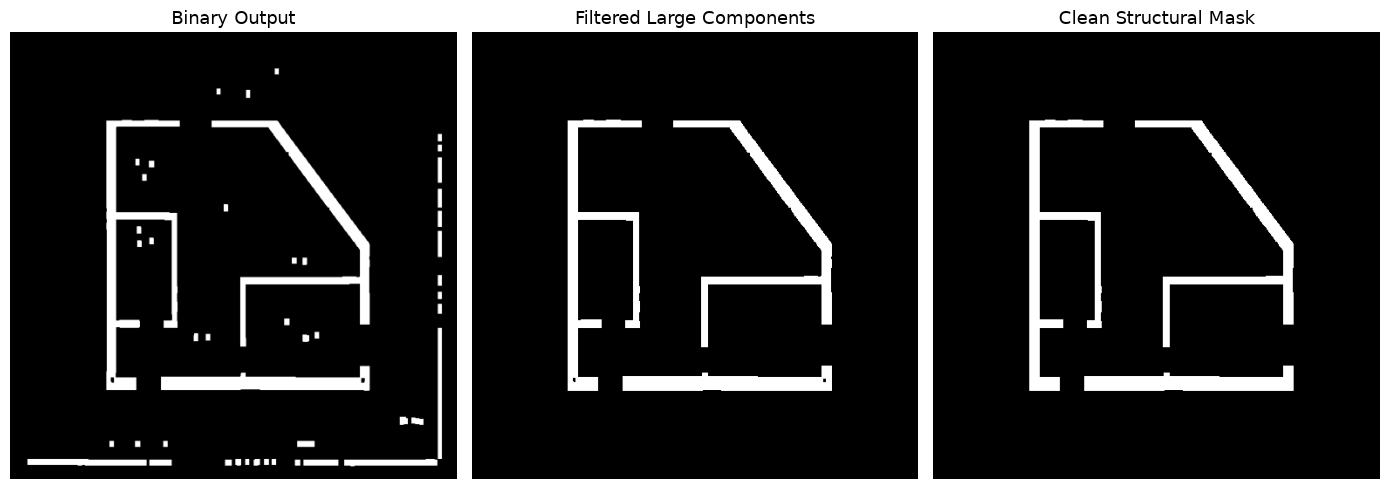

In [26]:
show_images(
    [binary, mask, clean_mask], 
    ["Binary Output", "Filtered Large Components", "Clean Structural Mask"],
    nrows=1, ncols=3,
    )

## Analyze Segmented Wall Components

Now we ask, how many separate wall structures remain after cleaning?

After removing small artifacts and strengthening the wall mask using morphological operations, connected component analysis is performed again to examine the final segmentation result. 

Each connected component represents one continuous wall structure. This step is mainly used for analysis and quality control, allowing us to verify whether the wall mask consists of a few large structural components instead of many fragmented pieces.

In [27]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    clean_mask.astype(np.uint8),
    connectivity=8
)

print(f"{num_labels-1} wall components")

3 wall components


## Extract contours

After obtaining a clean binary wall mask, the next step is to extract the geometric boundaries of the segmented structures. Instead of working with pixels, we convert the binary regions into contours, which represent continuous curves along object boundaries.

`cv2.findContours()` detects these boundaries by tracing the edges of connected white regions in the binary image. Each contour corresponds to one connected structure in the mask.

This step is important because it converts raster data (pixels) into vector-like representations, which can later be used for polygon approximation, measurement, and architectural structure analysis.

In [28]:
contours, hierarchy = cv2.findContours(
    clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

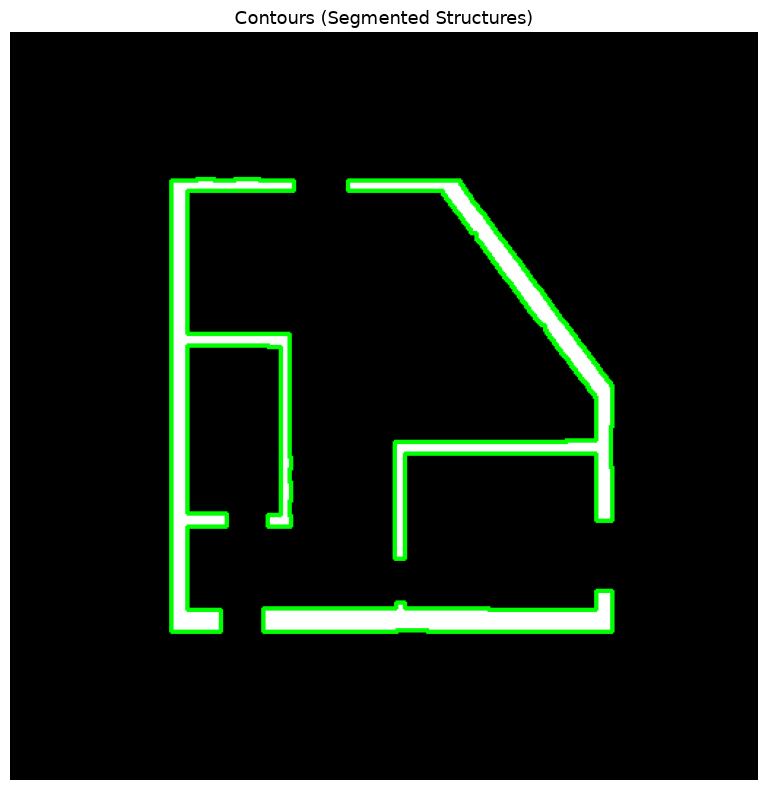

In [29]:
vis = cv2.cvtColor((clean_mask*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

cv2.drawContours(vis, contours, -1, (0,255,0), 2)

show_images(
    [vis],
    ["Contours (Segmented Structures)"],
    )

## Approximate polygons

After extracting wall contours, the next step is to convert these pixel-based boundaries into simplified geometric representations. Real contours contain hundreds or thousands of points due to pixel-level noise and discretization.

`cv2.approxPolyDP()` approximates a contour with a reduced number of points while preserving its overall shape. This converts irregular pixel boundaries into cleaner polygonal representations, which are easier to analyze, store, and use for downstream tasks such as vectorization or floor plan reconstruction.

The approximation accuracy is controlled by a parameter called epsilon, which defines the maximum allowed deviation between the original contour and the simplified polygon.

In [30]:
polygons = []

for cnt in contours:

    # Perimeter of contour
    perimeter = cv2.arcLength(cnt, True)

    # Approximation accuracy
    epsilon = 0.002 * perimeter

    # Simplify contour into polygon
    polygon = cv2.approxPolyDP(cnt, epsilon, True)

    polygons.append(polygon)

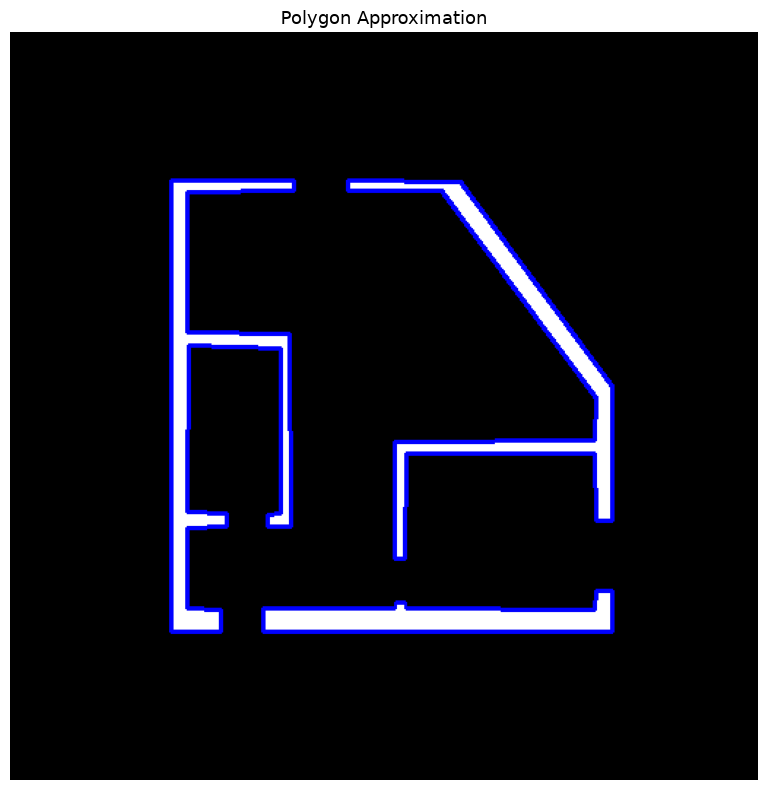

In [31]:
vis = cv2.cvtColor((clean_mask * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

for poly in polygons:
    cv2.polylines(vis, [poly], True, (0, 0, 255), 2)

show_images([vis], ["Polygon Approximation"])

## Saving results

In [32]:
with open("../output/polygons.pkl", "wb") as f:
    pickle.dump(polygons, f)